In [5]:
import kagglehub
kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


In [22]:
dataset_path = kagglehub.dataset_download('justin2028/us-immigration-statistics-1980-2021')

100%|██████████| 1.42k/1.42k [00:00<00:00, 1.22MB/s]

Extracting files...


In [23]:
import pandas as pd
import os
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import numpy as np

In [45]:
# All from analysis file (Possible Effects of Enforcement)
files = os.listdir(dataset_path)
print(files)

immigrations_df = pd.read_csv(os.path.join(dataset_path, files[0]))

['US Immigration Statistics (Ver 1.14.26).csv']


In [46]:
# Start of PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [47]:
# Features for PCA from Jackie
immigrations_df = immigrations_df[~immigrations_df['Year'].isin([1991, 2003, 2020, 2021, 2022])]

new_features = [
    "Immigrants Obtaining Lawful Permanent Resident Status",
    "Refugee Arrivals",
    "Noncitizen Apprehensions",
    "Noncitizen Removals",
    "Noncitizen Returns"
]

for f in new_features:
    immigrations_df[f] = (
        immigrations_df[f].str.replace(",", "").astype(float)
    )

x_new = immigrations_df[new_features]

In [48]:
scaler_new = StandardScaler()
x_new_scaled = scaler_new.fit_transform(x_new)

In [49]:
x_new_cleaned = x_new.dropna()

scaler_new_fixed = StandardScaler()
x_new_scaled_fixed = scaler_new_fixed.fit_transform(x_new_cleaned)

pca_new = PCA(n_components=2)
principal_components_new = pca_new.fit_transform(x_new_scaled_fixed)

In [50]:
print(f"Explained variance ratio per component for new PCA: {pca_new.explained_variance_ratio_}")

# Create a DataFrame to make the loadings easy to read for the new PCA
loadings_new = pd.DataFrame(
    pca_new.components_.T,
    columns=['PC1_New', 'PC2_New'],
    index=new_features
)

print("\nLoadings for new PCA (Weights of each variable in the components):")
print(loadings_new)

Explained variance ratio per component for new PCA: [0.57063625 0.24329035]

Loadings for new PCA (Weights of each variable in the components):
                                                     PC1_New   PC2_New
Immigrants Obtaining Lawful Permanent Resident ... -0.415543 -0.246663
Refugee Arrivals                                    0.257686  0.714104
Noncitizen Apprehensions                            0.482387 -0.479873
Noncitizen Removals                                -0.510126 -0.259940
Noncitizen Returns                                  0.517683 -0.362444


In [61]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Trying to predict Immigrants obtaining permanent residency
y_pcr = immigrations_df.loc[x_new_cleaned.index, 'Immigrants Obtaining Lawful Permanent Resident Status']
X_pcr = principal_components_new

X_train, X_test, y_train, y_test = train_test_split(X_pcr, y_pcr, test_size=0.2, random_state=42)

In [62]:
# Linear Reg model
pcr_model = LinearRegression()
pcr_model.fit(X_train, y_train)

y_pred = pcr_model.predict(X_test)

In [63]:
# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Principal Component Regression Model Performance:")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

print("\nCoefficients for Principal Components:")
for i, coef in enumerate(pcr_model.coef_):
    print(f"PC{i+1}: {coef:.2f}")

Principal Component Regression Model Performance:
Mean Squared Error (MSE): 12540935371.54
R-squared (R2): 0.75

Coefficients for Principal Components:
PC1: -102254.13
PC2: -62456.13


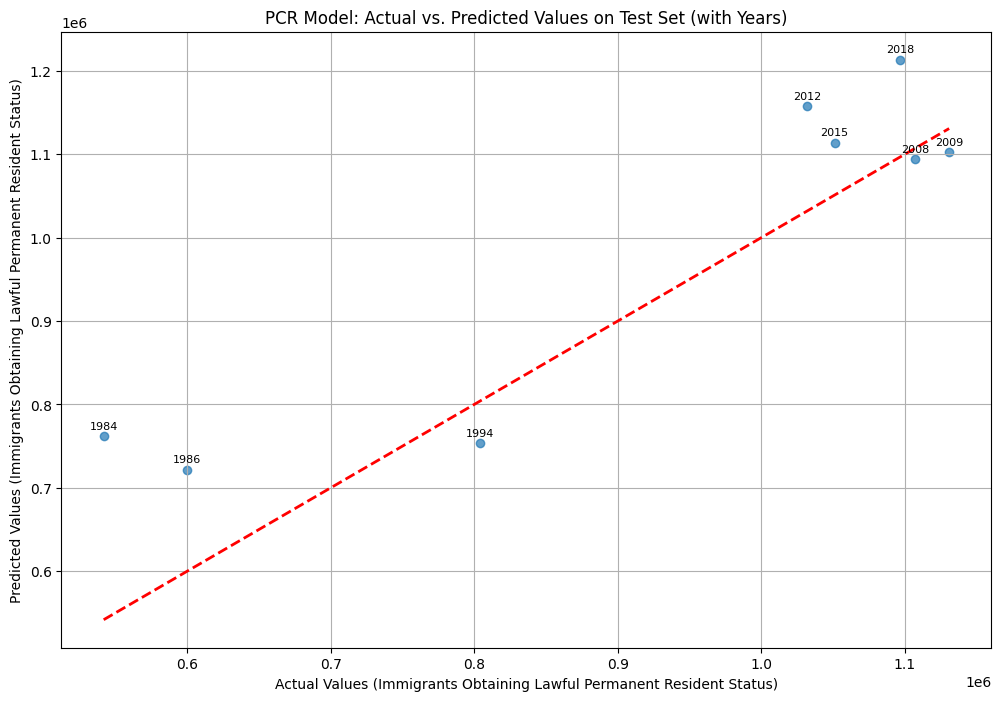

In [67]:
# Printing out test vs predicted data
plt.figure(figsize=(12, 8))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)

years_test = immigrations_df.loc[y_test.index, 'Year']

for i, year in enumerate(years_test):
    plt.annotate(int(year), (y_test.iloc[i], y_pred[i]), textcoords="offset points", xytext=(0,5), ha='center', fontsize=8)

plt.xlabel('Actual Values (Immigrants Obtaining Lawful Permanent Resident Status)')
plt.ylabel('Predicted Values (Immigrants Obtaining Lawful Permanent Resident Status)')
plt.title('PCR Model: Actual vs. Predicted Values on Test Set (with Years)')
plt.grid(True)
plt.show()

In [66]:
# MSE in this case is 12,540,935,371.54 which may seem like alot- however, this is only
# off by an average of 100,000 immigrants.